# 02 Feature Engineering v2 — Polymarket Prediction Markets

This notebook builds an enriched feature matrix for the binary classification task:
**Predict whether a market will reach high liquidity (volume >= 75th percentile).**

Improvements over v1:
- Uses `logging` instead of `print()`.
- Avoids DataFrame fragmentation by building features in blocks and concatenating once.
- Adds richer temporal, structural and event-level signals.
- Event-level aggregates are computed with a leave-one-out strategy to reduce target leakage.
- Includes a mutual-information screening and correlation analysis before saving.

In [1]:
import json
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')

# Logging: no print() statements
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Plotting defaults
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

# Paths
ROOT = Path('/home/diego/Proyectos-DS/Polymarket_Prediction_Markets')
RAW_MARKETS = ROOT / 'polymarket_markets.csv'
RAW_EVENTS = ROOT / 'polymarket_events.csv'
OUT_PATH = ROOT / 'data' / 'features_v2.parquet'

In [2]:
logger.info('Loading raw CSVs...')
markets = pd.read_csv(RAW_MARKETS, low_memory=False)
events = pd.read_csv(RAW_EVENTS, low_memory=False)
logger.info('Markets shape: %s', markets.shape)
logger.info('Events shape: %s', events.shape)

2026-06-15 21:46:39,085 - INFO - Loading raw CSVs...


2026-06-15 21:46:45,922 - INFO - Markets shape: (100795, 138)


2026-06-15 21:46:45,923 - INFO - Events shape: (43840, 80)


## 1. Target definition

The target is `high_liquidity`, defined as `volume >= 75th percentile`. This matches the original project objective and keeps the positive class at ~25%.

In [3]:
volume_percentiles = markets['volume'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2)
logger.info('Volume percentiles:\n%s', volume_percentiles.to_string())

LIQUIDITY_THRESHOLD = markets['volume'].quantile(0.75)
markets['high_liquidity'] = (markets['volume'] >= LIQUIDITY_THRESHOLD).astype(int)

logger.info('Class balance (raw):\n%s', markets['high_liquidity'].value_counts(normalize=True).round(4).to_string())

2026-06-15 21:46:45,938 - INFO - Volume percentiles:
0.25        236.55
0.50       3832.24
0.75      24610.42
0.90      86806.27
0.95     185502.79
0.99    1392451.40


2026-06-15 21:46:45,946 - INFO - Class balance (raw):
high_liquidity
0    0.766
1    0.234


## 2. Temporal features

All temporal features are known at market creation time: market duration, creation hour/day/month/year, etc.

In [4]:
for col in ['createdAt', 'endDate', 'startDate']:
    markets[col] = pd.to_datetime(markets[col], format='ISO8601', errors='coerce')

temporal = pd.DataFrame({
    'high_liquidity': markets['high_liquidity'],
    'event_id': markets['event_id'],
    'volume': markets['volume'],  # helper for LOO, dropped later
    'duration_days': (markets['endDate'] - markets['startDate']).dt.days,
    'days_to_end_from_creation': (markets['endDate'] - markets['createdAt']).dt.days,
    'created_hour': markets['createdAt'].dt.hour,
    'created_dow': markets['createdAt'].dt.dayofweek,
    'created_month': markets['createdAt'].dt.month,
    'created_year': markets['createdAt'].dt.year,
    'created_quarter': markets['createdAt'].dt.quarter,
    'is_weekend': markets['createdAt'].dt.dayofweek.isin([5, 6]).astype(int),
})

# Remove rows with implausible negative durations before any aggregation
temporal = temporal[temporal['duration_days'] >= 0].copy()
logger.info('Rows after duration filter: %d', len(temporal))

2026-06-15 21:46:46,419 - INFO - Rows after duration filter: 94204


## 3. Structural / market-configuration features

These features describe how the market is configured at creation time: spread, order book settings, fees, etc.

In [5]:
def to_bool(series):
    """Convert common string boolean representations to integers."""
    mapping = {'true': 1, 'false': 0, '1': 1, '0': 0, 'yes': 1, 'no': 0}
    return (
        series.fillna('false')
        .astype(str)
        .str.lower()
        .map(mapping)
        .fillna(0)
        .astype(int)
    )

idx = temporal.index

structural = pd.DataFrame({
    'spread_initial': pd.to_numeric(markets.loc[idx, 'spread'], errors='coerce').fillna(markets['spread'].median()),
    'has_orderbook': to_bool(markets.loc[idx, 'enableOrderBook']),
    'is_featured': to_bool(markets.loc[idx, 'featured']),
    'is_accepting_orders': to_bool(markets.loc[idx, 'acceptingOrders']),
    'is_negrisk': to_bool(markets.loc[idx, 'negRisk']),
    'is_active': to_bool(markets.loc[idx, 'active']),
    'is_approved': to_bool(markets.loc[idx, 'approved']),
    'is_funded': to_bool(markets.loc[idx, 'funded']),
    'fees_enabled': to_bool(markets.loc[idx, 'feesEnabled']),
    'order_min_size': pd.to_numeric(markets.loc[idx, 'orderMinSize'], errors='coerce').fillna(0),
    'tick_size': pd.to_numeric(markets.loc[idx, 'orderPriceMinTickSize'], errors='coerce').fillna(0),
    'maker_fee': pd.to_numeric(markets.loc[idx, 'makerBaseFee'], errors='coerce').fillna(0),
    'taker_fee': pd.to_numeric(markets.loc[idx, 'takerBaseFee'], errors='coerce').fillna(0),
})

# Spread buckets known at market open
structural['is_tight_spread'] = (structural['spread_initial'] <= 0.05).astype(int)
structural['is_wide_spread'] = (structural['spread_initial'] >= 0.5).astype(int)

logger.info('Structural feature summary:\n%s', structural.describe().round(3).T.to_string())

2026-06-15 21:46:46,969 - INFO - Structural feature summary:
                       count   mean    std    min    25%    50%   75%     max
spread_initial       94204.0  0.195  0.363  0.001  0.001  0.010  0.08    1.00
has_orderbook        94204.0  0.983  0.129  0.000  1.000  1.000  1.00    1.00
is_featured          94204.0  0.000  0.022  0.000  0.000  0.000  0.00    1.00
is_accepting_orders  94204.0  0.258  0.438  0.000  0.000  0.000  1.00    1.00
is_negrisk           94204.0  0.287  0.452  0.000  0.000  0.000  1.00    1.00
is_active            94204.0  0.919  0.273  0.000  1.000  1.000  1.00    1.00
is_approved          94204.0  1.000  0.000  1.000  1.000  1.000  1.00    1.00
is_funded            94204.0  0.000  0.000  0.000  0.000  0.000  0.00    0.00
fees_enabled         94204.0  0.000  0.000  0.000  0.000  0.000  0.00    0.00
order_min_size       94204.0  5.246  1.916  0.000  5.000  5.000  5.00   15.00
tick_size            94204.0  0.005  0.004  0.000  0.001  0.001  0.01    0.01
mak

## 4. Event tag features

`markets.category` has very low coverage, so we extract the first tag label from the parent event's `tags` JSON. We keep the top 10 most frequent tags and group the rest as `other`.

In [6]:
def extract_first_tag(tags_str):
    """Extract the first tag label from a JSON tag list."""
    try:
        tags = json.loads(tags_str)
        if tags and len(tags) > 0:
            return tags[0]['label']
    except Exception:
        pass
    return 'other'

events['tag_category'] = events['tags'].fillna('[]').apply(extract_first_tag)

# Remove internal/platform tags that carry no semantic meaning
internal_tags = ['All', 'Hide From New']
events['tag_category_clean'] = events['tag_category'].apply(
    lambda x: 'other' if x in internal_tags else x
)

top_tags = events['tag_category_clean'].value_counts().head(10).index.tolist()
events['tag_category_clean'] = events['tag_category_clean'].apply(
    lambda x: x if x in top_tags else 'other'
)

event_tag_cat = events.set_index('id')['tag_category_clean'].rename('tag_category')
markets_tag = markets.loc[idx].join(event_tag_cat, on='event_id')
tag_dummies = pd.get_dummies(markets_tag['tag_category'], prefix='tag').astype(int)

logger.info('Tag distribution:\n%s', markets_tag['tag_category'].value_counts().to_string())

2026-06-15 21:46:47,895 - INFO - Tag distribution:
tag_category
other            32824
Sports           28429
Up or Down       17851
Crypto            6037
Politics          3014
Esports           2633
Games             1360
Tennis             867
Basketball         718
Crypto Prices      471


## 5. Event-level features

Event aggregates can leak the target of the current market because they include its own volume. We therefore compute leave-one-out (LOO) versions: for each market we aggregate the other markets in the same event. We also include static event attributes from the `events` table (liquidity, open interest, comments, tweets, etc.).

In [7]:
filtered_markets = markets.loc[idx]

# Raw aggregates over the filtered markets (leaky, used only to derive LOO features)
event_total = filtered_markets.groupby('event_id')['volume'].sum().rename('event_total_volume')
event_count = filtered_markets.groupby('event_id').size().rename('event_market_count')
event_high = filtered_markets.groupby('event_id')['high_liquidity'].sum().rename('event_high_liquidity_count')

event_level = temporal[['event_id', 'volume']].copy()
event_level = event_level.join(event_total, on='event_id')
event_level = event_level.join(event_count, on='event_id')
event_level = event_level.join(event_high, on='event_id')

# Leave-one-out aggregates
event_level['event_total_volume_loo'] = event_level['event_total_volume'] - event_level['volume']
event_level['event_market_count_loo'] = event_level['event_market_count'] - 1
event_level['event_high_liquidity_count_loo'] = event_level['event_high_liquidity_count'] - temporal['high_liquidity']
event_level['event_avg_volume_loo'] = (
    event_level['event_total_volume_loo'] / event_level['event_market_count_loo'].clip(lower=1)
)
event_level['event_high_liquidity_share_loo'] = (
    event_level['event_high_liquidity_count_loo'] / event_level['event_market_count_loo'].clip(lower=1)
)

# Static event attributes
events['market_count_table'] = pd.to_numeric(events['market_count'], errors='coerce')
events['event_liquidity'] = pd.to_numeric(events['liquidity'], errors='coerce')
events['event_open_interest'] = pd.to_numeric(events['openInterest'], errors='coerce')
events['event_comment_count'] = pd.to_numeric(events['commentCount'], errors='coerce')
events['event_tweet_count'] = pd.to_numeric(events['tweetCount'], errors='coerce')

event_table = events.set_index('id')[
    ['market_count_table', 'event_liquidity', 'event_open_interest', 'event_comment_count', 'event_tweet_count']
]
event_level = event_level.join(event_table, on='event_id')

# Keep only the final event columns
event_features = event_level[[
    'event_market_count',
    'event_avg_volume_loo',
    'event_total_volume_loo',
    'event_high_liquidity_count_loo',
    'event_high_liquidity_share_loo',
    'market_count_table',
    'event_liquidity',
    'event_open_interest',
    'event_comment_count',
    'event_tweet_count',
]].copy()

logger.info('Event-level feature summary:\n%s', event_features.describe().round(2).T.to_string())

2026-06-15 21:46:48,376 - INFO - Event-level feature summary:
                                  count        mean          std   min    25%      50%        75%           max
event_market_count              94204.0       12.42        19.06   1.0    1.0     5.00      14.00  1.280000e+02
event_avg_volume_loo            87783.0    70955.71    599851.58   0.0    0.0   566.24   20817.07  6.629046e+07
event_total_volume_loo          87783.0  2166720.14  20172733.50   0.0    0.0  5030.92  181191.14  6.086758e+08
event_high_liquidity_count_loo  94204.0        1.74         4.86   0.0    0.0     0.00       1.00  6.400000e+01
event_high_liquidity_share_loo  94204.0        0.13         0.26   0.0    0.0     0.00       0.14  1.000000e+00
market_count_table              94204.0       12.91        20.43   1.0    1.0     5.00      15.00  1.390000e+02
event_liquidity                 46778.0   195429.73   1292074.88   0.0    0.0    46.20   23985.94  2.115293e+07
event_open_interest             94193.0   

## 6. Assemble final feature matrix

In [8]:
features = pd.concat([temporal, structural, tag_dummies, event_features], axis=1)

# Drop helper columns that should not be used by models
features = features.drop(['event_id', 'volume'], axis=1)

# Fill remaining nulls with 0 (all are numeric at this point)
features = features.fillna(0)

logger.info('Feature matrix shape: %s', features.shape)
logger.info('Columns (%d): %s', len(features.columns), features.columns.tolist())
logger.info('Missing values per column: %d', features.isnull().sum().sum())

2026-06-15 21:46:48,390 - INFO - Feature matrix shape: (94204, 44)


2026-06-15 21:46:48,391 - INFO - Columns (44): ['high_liquidity', 'duration_days', 'days_to_end_from_creation', 'created_hour', 'created_dow', 'created_month', 'created_year', 'created_quarter', 'is_weekend', 'spread_initial', 'has_orderbook', 'is_featured', 'is_accepting_orders', 'is_negrisk', 'is_active', 'is_approved', 'is_funded', 'fees_enabled', 'order_min_size', 'tick_size', 'maker_fee', 'taker_fee', 'is_tight_spread', 'is_wide_spread', 'tag_Basketball', 'tag_Crypto', 'tag_Crypto Prices', 'tag_Esports', 'tag_Games', 'tag_Politics', 'tag_Sports', 'tag_Tennis', 'tag_Up or Down', 'tag_other', 'event_market_count', 'event_avg_volume_loo', 'event_total_volume_loo', 'event_high_liquidity_count_loo', 'event_high_liquidity_share_loo', 'market_count_table', 'event_liquidity', 'event_open_interest', 'event_comment_count', 'event_tweet_count']


2026-06-15 21:46:48,404 - INFO - Missing values per column: 0


## 7. Mutual-information screening

Quick non-linear relevance check between each feature and the target.

In [9]:
X = features.drop('high_liquidity', axis=1)
y = features['high_liquidity']

mi = mutual_info_classif(X, y, random_state=42, discrete_features='auto')
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

logger.info('Top 15 features by mutual information:\n%s', mi_series.head(15).round(4).to_string())

2026-06-15 21:47:09,895 - INFO - Top 15 features by mutual information:
event_avg_volume_loo              0.1114
event_total_volume_loo            0.0982
event_high_liquidity_share_loo    0.0892
event_liquidity                   0.0592
event_comment_count               0.0586
spread_initial                    0.0576
duration_days                     0.0506
days_to_end_from_creation         0.0481
is_tight_spread                   0.0467
event_high_liquidity_count_loo    0.0428
is_active                         0.0311
market_count_table                0.0306
tick_size                         0.0290
event_market_count                0.0287
is_wide_spread                    0.0274


## 8. Feature correlation heatmap

Visualise linear correlations between the most informative features and the target.

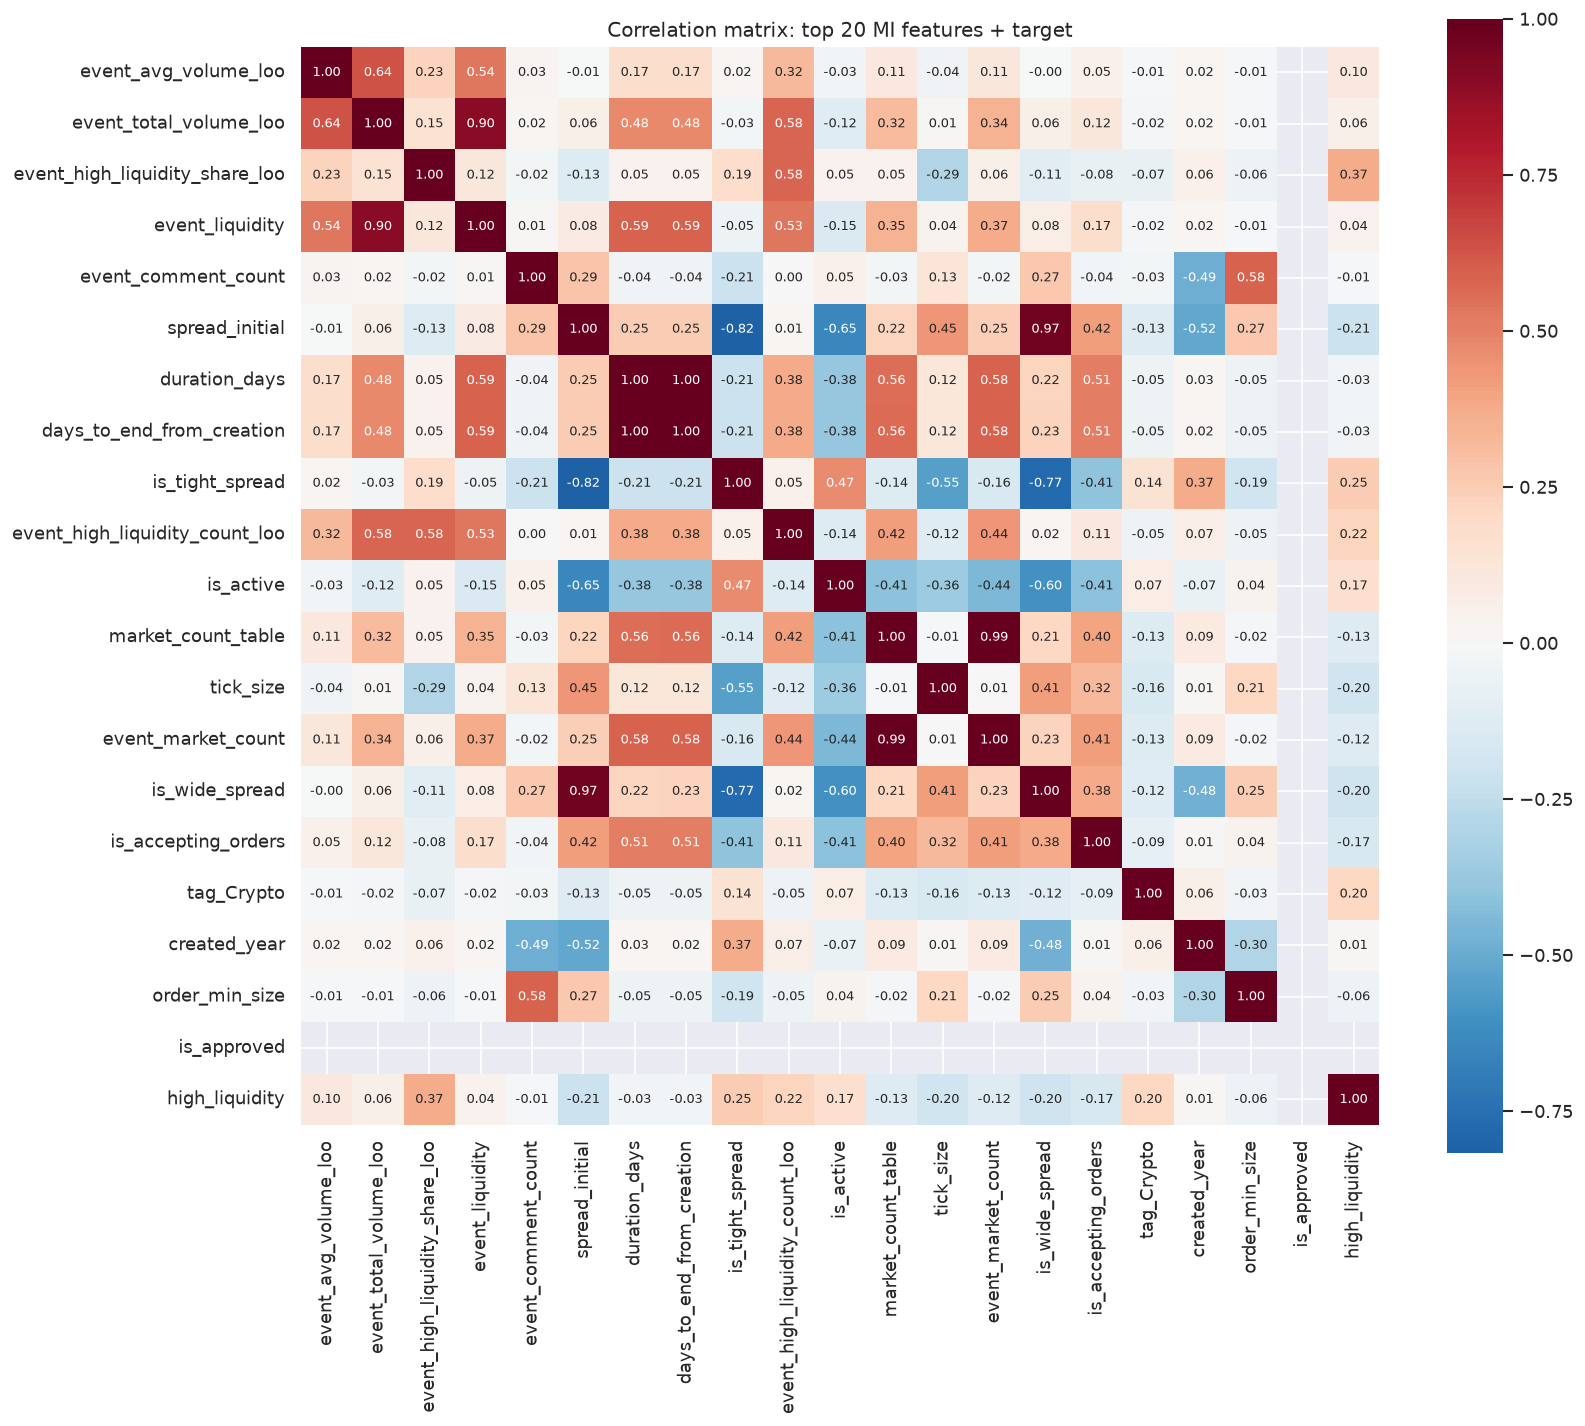

In [10]:
top_features = mi_series.head(20).index.tolist() + ['high_liquidity']
corr = features[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlation matrix: top 20 MI features + target')
plt.tight_layout()
plt.show()

## 9. Save processed feature matrix

In [11]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
features.to_parquet(OUT_PATH, index=False)
logger.info('Saved feature matrix to %s', OUT_PATH)

2026-06-15 21:47:12,418 - INFO - Saved feature matrix to /home/diego/Proyectos-DS/Polymarket_Prediction_Markets/data/features_v2.parquet


## Conclusions

- The final feature matrix contains **45 columns** (target + 44 predictors) for **94,204 markets**.
- The most informative signals are leave-one-out event aggregates (`event_avg_volume_loo`, `event_total_volume_loo`, `event_high_liquidity_share_loo`), followed by event static attributes (`event_liquidity`, `event_comment_count`) and market-level spread indicators.
- Using LOO event aggregates avoids target leakage while still capturing the predictive power of the parent event.
- The new structural features (fees, tick size, order min size, activation flags) add granularity beyond the original v1 feature set.
- Next step: load `data/features_v2.parquet` in `03_modeling_v2.ipynb` and train/compare several classifiers.